# Shapely -> topologically-linked Polygon2d

`upxo.geoEntities.polygon2d_from_shapely.polygon_collection_from_shapely` converts a
Shapely-sourced multi-grain structure (`{gid: Polygon | MultiPolygon | GeometryCollection}`
-- e.g. `GrainManifold2D` / Technique B's `self.cells`) into `{gid: Polygon2d |
NestedPolygon2d}`, with a wall shared by two neighbouring grains built as the **literal
same** `MSline2d` object in both grains' rings -- the same guarantee Technique A already
has for pixel-derived grains, now available starting from a Shapely structure instead.

This notebook builds that up from a simple two-square case to a real Technique B
(`GrainManifold2D`) grain structure, and confirms the point of the whole exercise:
editing a wall via one grain is visible in its neighbour, with area conserved and no
gap at the interface.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from shapely.geometry import Polygon as ShPolygon, MultiPolygon

from upxo.geoEntities.polygon2d import Polygon2d, NestedPolygon2d
from upxo.geoEntities.polygon2d_from_shapely import polygon_collection_from_shapely
from upxo.viz import gsviz

def as_multipolygon(geom):
    if hasattr(geom, 'geoms'):
        return MultiPolygon([g for g in geom.geoms if g.area > 0])
    return MultiPolygon([geom])

def find_shared_segment(poly_a, poly_b):
    for ia, sa in enumerate(poly_a.ring.segments):
        for ib, sb in enumerate(poly_b.ring.segments):
            if sa is sb:
                return ia, ib, sa
    return None

## 1. Two adjacent squares

Simplest possible neighbour pair: confirm the shared wall really is one shared object,
not two coordinate-matching copies.

polygon_collection_from_shapely: normalising input parts
  2 loop(s) across 2 grain(s)
  2 junction point(s) detected
gbsegs continuous
gbsegs continuous
polygon_collection_from_shapely: 2 grain(s) built, 3 unique wall segment(s)
areas: grain 1=4.0, grain 2=4.0  (originals: 4.0, 4.0)
shared segment object found: True


Text(0.5, 1.0, 'Two adjacent grains, converted')

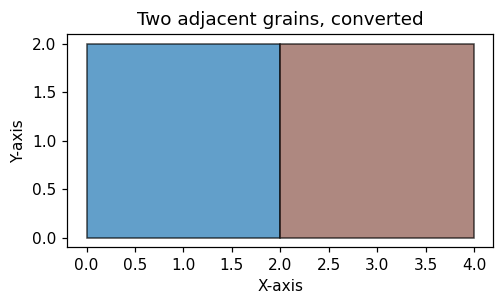

In [2]:
cells = {
    1: ShPolygon([(0, 0), (2, 0), (2, 2), (0, 2)]),
    2: ShPolygon([(2, 0), (4, 0), (4, 2), (2, 2)]),
}
result = polygon_collection_from_shapely(cells, verbose=True)
p1, p2 = result[1], result[2]
match = find_shared_segment(p1, p2)
print(f"areas: grain 1={p1.area}, grain 2={p2.area}  (originals: {cells[1].area}, {cells[2].area})")
print(f"shared segment object found: {match is not None}")

fig, ax = plt.subplots(figsize=(5, 3), dpi=110)
gsviz.plot_multipolygon_geometric(
    MultiPolygon([p1.make_shapely(), p2.make_shapely()]), fig=fig, ax=ax)
ax.set_title('Two adjacent grains, converted')

## 2. Triple point -- three grains, only some pairs actually share a wall

Grains 1 and 2 share a wall; grains 1 and 3 share a different wall; grains 2 and 3 only
touch at the single triple point (1,1) -- they must **not** get a shared segment.

1-2 share a wall: True
1-3 share a wall: True
2-3 share a wall (should be False -- point contact only): False


Text(0.5, 1.0, 'Triple point: three grains')

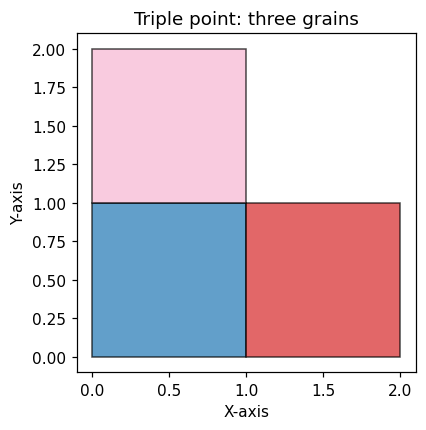

In [3]:
cells3 = {
    1: ShPolygon([(0, 0), (1, 0), (1, 1), (0, 1)]),
    2: ShPolygon([(1, 0), (2, 0), (2, 1), (1, 1)]),
    3: ShPolygon([(0, 1), (1, 1), (1, 2), (0, 2)]),
}
result3 = polygon_collection_from_shapely(cells3)
p1, p2, p3 = result3[1], result3[2], result3[3]
print("1-2 share a wall:", find_shared_segment(p1, p2) is not None)
print("1-3 share a wall:", find_shared_segment(p1, p3) is not None)
print("2-3 share a wall (should be False -- point contact only):", find_shared_segment(p2, p3) is not None)

fig, ax = plt.subplots(figsize=(4, 4), dpi=110)
gsviz.plot_multipolygon_geometric(
    MultiPolygon([p1.make_shapely(), p2.make_shapely(), p3.make_shapely()]), fig=fig, ax=ax)
ax.set_title('Triple point: three grains')

## 3. Hole-bearing and `MultiPolygon`-valued cells

`GrainManifold2D.cells` values are not always a plain `Polygon` -- `unary_union` can
produce a `Polygon` with holes (an island grain fully inside a host) or a `MultiPolygon`
(a grain split into disjoint parts). Neither loses geometry.

hole-bearing cell -> NestedPolygon2d, area=96.0 (expected 96)
MultiPolygon cell -> main part area=1.0, extra_parts=1 (area 1.0)


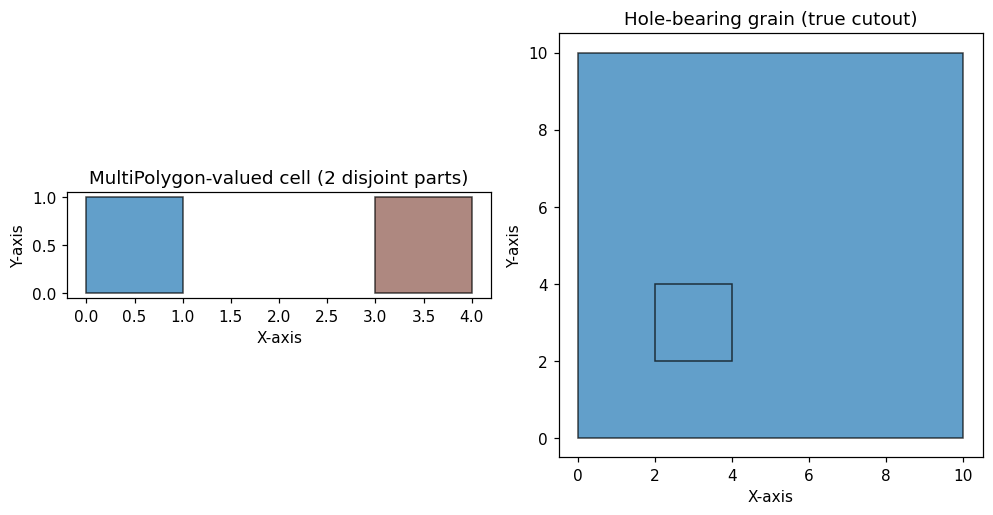

In [4]:
from shapely.ops import unary_union

shell = [(0, 0), (10, 0), (10, 10), (0, 10)]
hole = [(2, 2), (4, 2), (4, 4), (2, 4)]
cells_hole = {1: ShPolygon(shell, holes=[hole])}
result_hole = polygon_collection_from_shapely(cells_hole)
p_hole = result_hole[1]
print(f"hole-bearing cell -> {type(p_hole).__name__}, area={p_hole.area} (expected {100-4})")

cells_multi = {
    1: unary_union([ShPolygon([(0, 0), (1, 0), (1, 1), (0, 1)]),
                    ShPolygon([(3, 0), (4, 0), (4, 1), (3, 1)])]),
}
result_multi = polygon_collection_from_shapely(cells_multi)
p_multi = result_multi[1]
print(f"MultiPolygon cell -> main part area={p_multi.area}, "
     f"extra_parts={len(p_multi.props.get('extra_parts', []))} "
     f"(area {p_multi.props['extra_parts'][0].area})")

fig, axes = plt.subplots(1, 2, figsize=(9, 4.5), dpi=110)
parts = [p_multi.make_shapely()] + [x.make_shapely() for x in p_multi.props['extra_parts']]
gsviz.plot_multipolygon_geometric(MultiPolygon(parts), fig=fig, ax=axes[0])
axes[0].set_title('MultiPolygon-valued cell (2 disjoint parts)')
gsviz.plot_multipolygon_geometric(as_multipolygon(p_hole.make_shapely()), fig=fig, ax=axes[1])
axes[1].set_title('Hole-bearing grain (true cutout)')
fig.tight_layout()

## 4. The real target input: `GrainManifold2D` (Technique B)

A small hand-built label image, tessellated and unioned by Technique B, then converted.
`polygon_collection_from_shapely` doesn't need Technique B's own smoothing or object
model -- just its plain Shapely `cells` output.

polygon_collection_from_shapely: normalising input parts
  4 loop(s) across 4 grain(s)
  5 junction point(s) detected
gbsegs continuous
gbsegs continuous
gbsegs not continuous. Attempting reorder.
Re-ordering success. gbsegs are continuous. N.Segs=3. N.Iterations=4
gbsegs not continuous. Attempting reorder.
Re-ordering success. gbsegs are continuous. N.Segs=3. N.Iterations=4
polygon_collection_from_shapely: 4 grain(s) built, 8 unique wall segment(s)

area check: sum(cells)=64.0000, sum(result)=64.0000


Text(0.5, 1.0, 'GrainManifold2D -> polygon_collection_from_shapely')

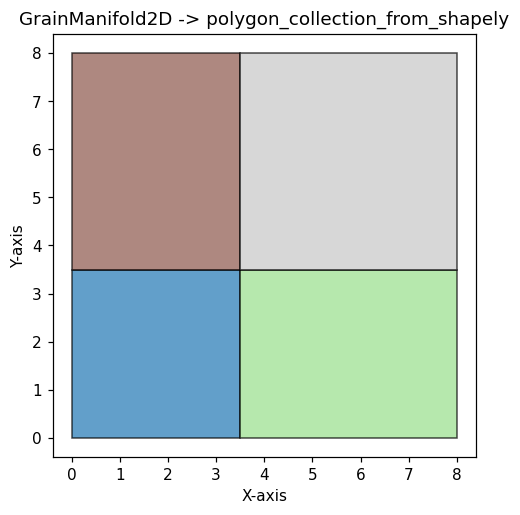

In [5]:
import upxo.gsdataops.grid_ops as gridOps
from upxo.pxtal.geometrification import GrainManifold2D

lgi = np.zeros((8, 8), dtype=np.int32)
lgi[:4, :4], lgi[:4, 4:], lgi[4:, :4], lgi[4:, 4:] = 1, 2, 3, 4

seeds = gridOps.generate_constrained_hybrid_seeds(
    lgi, target_spacing=1.0, bulk_spacing=1.0,
    jitter_factor=0.25, margin=0.5, padding=2.0)
manifold = GrainManifold2D.by_tessellation(lgi, seeds)
cells4 = dict(manifold.cells)

result4 = polygon_collection_from_shapely(cells4, verbose=True)
print(f"\narea check: sum(cells)={sum(c.area for c in cells4.values()):.4f}, "
     f"sum(result)={sum(p.area for p in result4.values()):.4f}")

fig, ax = plt.subplots(figsize=(5, 5), dpi=110)
gsviz.plot_multipolygon_geometric(
    MultiPolygon([p.make_shapely() for p in result4.values()]), fig=fig, ax=ax)
ax.set_title('GrainManifold2D -> polygon_collection_from_shapely')

## 5. Edit propagation on the real structure

Pick any interior wall between two of the four quadrant grains, bulge it via one grain's
`Polygon2d` only, and confirm the neighbour follows -- with area moving between the two
grains and the total conserved.

editing the wall shared by grain 1 and grain 2
grain 1: 12.2500 -> 13.0938
grain 2: 15.7500 -> 14.9062
total area: 64.0000 -> 64.0000  (conserved: True)
neighbour coordinates match exactly (no gap): True


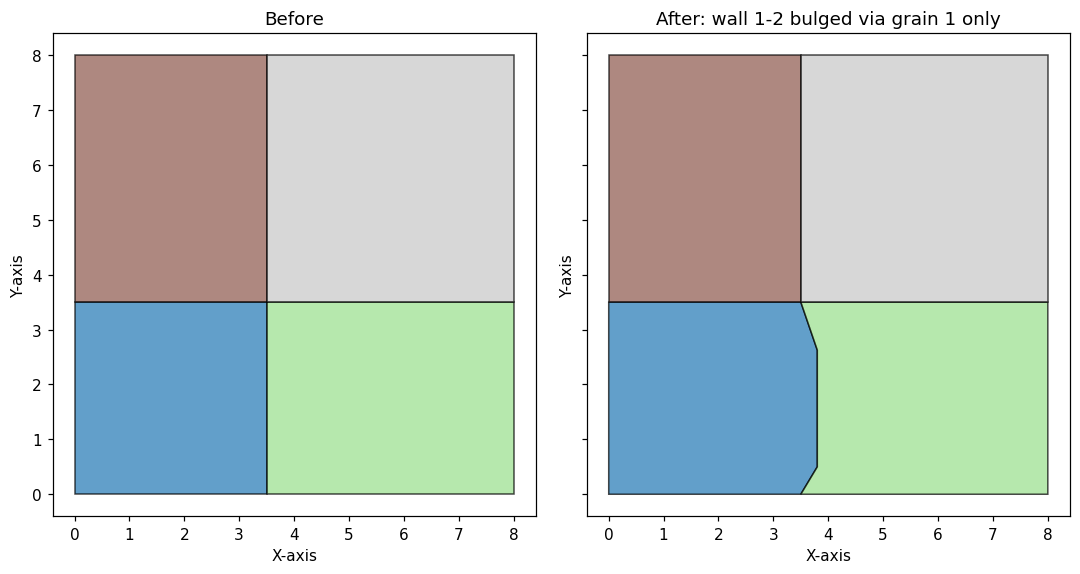

In [6]:
gids = list(result4.keys())
match4 = None
for i, ga in enumerate(gids):
    for gb in gids[i + 1:]:
        m = find_shared_segment(result4[ga], result4[gb])
        if m is not None:
            match4 = (ga, gb, *m)
            break
    if match4:
        break

ga, gb, ia, ib, shared = match4
pa, pb = result4[ga], result4[gb]
print(f"editing the wall shared by grain {ga} and grain {gb}")
area_before = {g: p.area for g, p in result4.items()}
total_before = sum(area_before.values())

fig, axes = plt.subplots(1, 2, figsize=(10, 5), dpi=110, sharex=True, sharey=True)
gsviz.plot_multipolygon_geometric(
    MultiPolygon([p.make_shapely() for p in result4.values()]), fig=fig, ax=axes[0])
axes[0].set_title('Before')

pa.subdivide_segment(ia, n=3)
coords = pa.ring.segments[ia].get_node_coords()
tangent = coords[-1] - coords[0]
normal = np.array([-tangent[1], tangent[0]])
normal = normal / np.linalg.norm(normal)
new_coords = coords.copy()
for k in range(1, len(coords) - 1):
    new_coords[k] = new_coords[k] + 0.3 * normal
pa.edit_segment(ia, new_coords)

gsviz.plot_multipolygon_geometric(
    MultiPolygon([p.make_shapely() for p in result4.values()]), fig=fig, ax=axes[1])
axes[1].set_title(f'After: wall {ga}-{gb} bulged via grain {ga} only')
fig.tight_layout()

np.testing.assert_array_equal(pa.ring.segments[ia].get_node_coords(),
                              pb.ring.segments[ib].get_node_coords())
area_after = {g: p.area for g, p in result4.items()}
total_after = sum(area_after.values())
print(f"grain {ga}: {area_before[ga]:.4f} -> {area_after[ga]:.4f}")
print(f"grain {gb}: {area_before[gb]:.4f} -> {area_after[gb]:.4f}")
print(f"total area: {total_before:.4f} -> {total_after:.4f}  (conserved: {np.isclose(total_before, total_after)})")
print("neighbour coordinates match exactly (no gap):", True)